In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix, hstack, eye
from tqdm.auto import tqdm

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from lightfm import LightFM

sns.set_style('whitegrid')


SEARCH_K = 10
N_TRIALS = 30
SEARCH_EPOCHS = 10
FINAL_EPOCHS = 20
EVAL_USERS_QUICK = 500
NUM_THREADS = 4


cluster_user_feats = {}

# Path к кластерным меткам (используется в секции 2)
CLUSTER_PATH = '../data/children_products/cluster_labels.csv'


## 1. Загрузка и подготовка данных

Источник — те же доставленные неотменённые заказы, что и в `lightfm_features.ipynb`. Итеративный
прунинг users/items с < 5 взаимодействиями, временной сплит по 80-му перцентилю даты последнего
взаимодействия пары (user, item). Cold-cohort (юзеры впервые появились после `split_ts`)
сохраняется отдельно для секции 8.

In [27]:
# === SHARED DATA PREP (do not edit without syncing across all 3 notebooks) ===
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

SEED = 42
DATA_PATH = '../data/children_products/clildren_product_cleaned.csv'
MIN_INTERACTIONS = 3
SPLIT_QUANTILE = 0.7
K_VALUES = [5, 10, 20]


In [28]:
# === SHARED DATA PREP ===
df = pd.read_csv(DATA_PATH, low_memory=False)
df = df[(df['Статус'] == 'Доставлен') & (df['Отменено'] == 'Нет')].copy()
df = df.dropna(subset=['Телефон_new', 'ID_SKU', 'Дата'])
df['Дата'] = pd.to_datetime(df['Дата'], errors='coerce')
df = df.dropna(subset=['Дата'])

if 'Цена' in df.columns:
    df['Цена'] = df['Цена'].astype(str).str.replace(' ', '').str.replace(',', '.')
    df['Цена'] = pd.to_numeric(df['Цена'], errors='coerce')

uc = df.groupby('Телефон_new').size()
ic = df.groupby('ID_SKU').size()
df = df[
    df['Телефон_new'].isin(uc[uc >= MIN_INTERACTIONS].index) &
    df['ID_SKU'].isin(ic[ic >= MIN_INTERACTIONS].index)
]
print(f'After filter: users={df["Телефон_new"].nunique():,}, '
      f'items={df["ID_SKU"].nunique():,}, rows={len(df):,}')


After filter: users=35,395, items=22,198, rows=314,493


In [29]:
# === SHARED DATA PREP ===
interactions = (
    df.groupby(['Телефон_new', 'ID_SKU'])
      .agg(last_date=('Дата', 'max'),
           mean_date=('Дата', 'mean'),
           count=('Дата', 'count'))
      .reset_index()
)

user_enc = LabelEncoder()
item_enc = LabelEncoder()
interactions['user_id'] = user_enc.fit_transform(interactions['Телефон_new'])
interactions['item_id'] = item_enc.fit_transform(interactions['ID_SKU'])

N_USERS = interactions['user_id'].nunique()
N_ITEMS = interactions['item_id'].nunique()
print(f'Unique pairs: {len(interactions):,}, N_USERS={N_USERS:,}, N_ITEMS={N_ITEMS:,}')


Unique pairs: 287,360, N_USERS=35,395, N_ITEMS=22,198


In [30]:
# === SHARED DATA PREP ===
split_ts = interactions['last_date'].quantile(SPLIT_QUANTILE)
print(f'Split timestamp: {split_ts}')

train_df = interactions[interactions['last_date'] <  split_ts].copy()
test_df  = interactions[interactions['last_date'] >= split_ts].copy()

train_users = set(train_df['user_id'].unique())
test_warm = test_df[ test_df['user_id'].isin(train_users)].copy()
test_cold = test_df[~test_df['user_id'].isin(train_users)].copy()

print(f'Train:     {len(train_df):,} pairs / {train_df["user_id"].nunique():,} users')
print(f'Test warm: {len(test_warm):,} pairs / {test_warm["user_id"].nunique():,} users')
print(f'Test cold: {len(test_cold):,} pairs / {test_cold["user_id"].nunique():,} users')

# Sanity: no leakage between train and test (same (user, item) pairs cannot appear in both)
_leak = train_df.merge(test_df, on=['user_id', 'item_id'])
assert len(_leak) == 0, f'Leakage: {len(_leak)} pairs in both train and test'


Split timestamp: 2017-04-12 17:37:00
Train:     201,147 pairs / 28,017 users
Test warm: 42,415 pairs / 7,128 users
Test cold: 43,798 pairs / 7,378 users


In [31]:
# === Adapter: имена, ожидаемые остальной частью notebook ===
np.random.seed(SEED)

n_users = N_USERS
n_items = N_ITEMS

from scipy.sparse import csr_matrix

def _build_sparse(d):
    return csr_matrix(
        (np.ones(len(d)), (d['user_id'].values, d['item_id'].values)),
        shape=(n_users, n_items),
    )

train_matrix = _build_sparse(train_df)
test_matrix  = _build_sparse(test_warm)

# Имена test_df / test_df_cold ожидаются secs 2-7
test_df      = test_warm
test_df_cold = test_cold

# train_raw: сырые (недедуплицированные) train-строки для feature aggregation
# (mode гео, mean цены и т.д.). Фильтр по дате эквивалентен фильтру по парам train_df,
# т.к. дедупликация и сплит делались по last_date.
train_raw = df.merge(
    interactions[['Телефон_new', 'ID_SKU', 'user_id', 'item_id']],
    on=['Телефон_new', 'ID_SKU'],
)
train_raw = train_raw[train_raw['Дата'] < split_ts].copy()

# Алиас для совместимости со старым кодом feature-агрегации
df_filtered = df

print(f'n_users={n_users:,}, n_items={n_items:,}')
print(f'Train matrix: {train_matrix.shape}, nnz={train_matrix.nnz:,}')
print(f'Test  matrix: {test_matrix.shape},  nnz={test_matrix.nnz:,}')
print(f'train_raw rows: {len(train_raw):,}')


n_users=35,395, n_items=22,198
Train matrix: (35395, 22198), nnz=201,147
Test  matrix: (35395, 22198),  nnz=42,415
train_raw rows: 225,586


In [32]:
user_agg = train_raw.groupby('Телефон_new').agg(
    geo_mode=('Гео', lambda x: x.mode().iloc[0] if len(x) > 0 else 'Регионы'),
    delivery_mode=('МетодДоставки', lambda x: x.mode().iloc[0] if len(x) > 0 else 'Unknown'),
    avg_price=('Цена', 'mean'),
    n_orders=('НомерЗаказаНаСайте', 'nunique'),
).reset_index()
user_agg['user_id'] = user_agg['Телефон_new'].map(user2id)
user_agg = user_agg.dropna(subset=['user_id']).copy()
user_agg['user_id'] = user_agg['user_id'].astype(int)

user_agg['price_bin'] = pd.qcut(
    user_agg['avg_price'], q=3,
    labels=['price_low', 'price_mid', 'price_high'], duplicates='drop',
).astype(str)
user_agg['orders_bin'] = pd.qcut(
    user_agg['n_orders'].rank(method='first'), q=3,
    labels=['orders_low', 'orders_mid', 'orders_high'],
).astype(str)

def group_delivery(method):
    method = str(method)
    if 'Курьерская' in method:
        return 'delivery_courier'
    if 'Магазины' in method or 'Самовывоз' in method:
        return 'delivery_store'
    return 'delivery_pickup'

user_agg['delivery_group'] = user_agg['delivery_mode'].apply(group_delivery)
user_agg['geo_feature'] = 'geo_' + user_agg['geo_mode'].astype(str)

base_user_feats = {
    int(row['user_id']): [
        row['geo_feature'],
        row['delivery_group'],
        row['price_bin'],
        row['orders_bin'],
    ]
    for _, row in user_agg.iterrows()
}

USER_FEATURE_GROUPS = {
    'geo':      sorted({f for fs in base_user_feats.values() for f in fs if f.startswith('geo_')}),
    'delivery': sorted({f for fs in base_user_feats.values() for f in fs if f.startswith('delivery_')}),
    'price':    sorted({f for fs in base_user_feats.values() for f in fs if f.startswith('price_')}),
    'orders':   sorted({f for fs in base_user_feats.values() for f in fs if f.startswith('orders_')}),
}
for k, v in USER_FEATURE_GROUPS.items():
    print(f'  user_{k:9s}: {len(v):2d} фич  →  {v}')
print(f'\nПользователей с базовыми фичами: {len(base_user_feats):,} / {n_users:,}')

  user_geo      :  3 фич  →  ['geo_МО', 'geo_Москва', 'geo_Регионы']
  user_delivery :  3 фич  →  ['delivery_courier', 'delivery_pickup', 'delivery_store']
  user_price    :  3 фич  →  ['price_high', 'price_low', 'price_mid']
  user_orders   :  3 фич  →  ['orders_high', 'orders_low', 'orders_mid']

Пользователей с базовыми фичами: 14,767 / 35,395


In [33]:
item_agg = train_raw.groupby('ID_SKU').agg(
    group2_mode=('Группа2', lambda x: x.mode().iloc[0] if len(x) > 0 else 'Unknown'),
    group3_mode=('Группа3', lambda x: x.mode().iloc[0] if len(x) > 0 else 'Unknown'),
    type_mode=('Тип', lambda x: x.mode().iloc[0] if len(x) > 0 else 'Unknown'),
    avg_price=('Цена', 'mean'),
).reset_index()
item_agg['item_id'] = item_agg['ID_SKU'].map(item2id)
item_agg = item_agg.dropna(subset=['item_id']).copy()
item_agg['item_id'] = item_agg['item_id'].astype(int)

item_agg['item_price_bin'] = pd.qcut(
    item_agg['avg_price'], q=4,
    labels=['item_cheap', 'item_budget', 'item_mid', 'item_premium'],
    duplicates='drop',
).astype(str)
item_agg['group2_feat'] = 'g2_'   + item_agg['group2_mode'].astype(str)
item_agg['group3_feat'] = 'g3_'   + item_agg['group3_mode'].astype(str)
item_agg['type_feat']   = 'type_' + item_agg['type_mode'].astype(str)

base_item_feats = {
    int(row['item_id']): [
        row['group2_feat'],
        row['group3_feat'],
        row['type_feat'],
        row['item_price_bin'],
    ]
    for _, row in item_agg.iterrows()
}

ITEM_FEATURE_GROUPS = {
    'g2':    sorted({f for fs in base_item_feats.values() for f in fs if f.startswith('g2_')}),
    'g3':    sorted({f for fs in base_item_feats.values() for f in fs if f.startswith('g3_')}),
    'type':  sorted({f for fs in base_item_feats.values() for f in fs if f.startswith('type_')}),
    'price': sorted({f for fs in base_item_feats.values() for f in fs if f.startswith('item_')}),
}
for k, v in ITEM_FEATURE_GROUPS.items():
    print(f'  item_{k:5s}: {len(v):3d} фич')
print(f'\nТоваров с базовыми фичами: {len(base_item_feats):,} / {n_items:,}')

  item_g2   :  13 фич
  item_g3   :  71 фич
  item_type :   5 фич
  item_price:   4 фич

Товаров с базовыми фичами: 8,363 / 22,198


In [34]:
import os

cluster_user_feats = {}
train_users_set = set(train_df['user_id'].unique())
cold_users_set  = set(test_df_cold['user_id'].unique())

if not os.path.exists(CLUSTER_PATH):
    print(f'!!! Файл {CLUSTER_PATH} не найден — кластерные фичи будут пустыми.')
    print('    (Запустите source/segments_users.ipynb, чтобы сгенерировать его.)')
else:
    cluster_df = pd.read_csv(CLUSTER_PATH)
    cluster_df['user_id'] = cluster_df['phone'].map(user2id)
    cluster_df = cluster_df.dropna(subset=['user_id']).copy()
    cluster_df['user_id'] = cluster_df['user_id'].astype(int)

    cluster_user_feats = {
        int(row['user_id']): [f"cluster_{int(row['kmeans_cluster'])}"]
        for _, row in cluster_df.iterrows()
    }

    covered_train = sum(1 for uid in train_users_set if uid in cluster_user_feats)
    covered_cold  = sum(1 for uid in cold_users_set  if uid in cluster_user_feats)
    cov_train = covered_train / max(len(train_users_set), 1)
    cov_cold  = covered_cold  / max(len(cold_users_set), 1)

    print(f'Кластерных меток найдено: {len(cluster_user_feats):,} / {n_users:,} users')
    print(f'  warm-train: {cov_train:.1%}  ({covered_train:,} / {len(train_users_set):,})')
    print(f'  cold-test:  {cov_cold:.1%}  ({covered_cold:,} / {len(cold_users_set):,})')
    if cov_train < 0.9:
        print('    ВНИМАНИЕ: покрытие train < 90%. Возможно cluster_labels.csv устарел.')
    if cov_cold < 0.5 and len(cold_users_set) > 0:
        print('    ВНИМАНИЕ: покрытие cold < 50% — кластеры почти не помогут cold-start eval.')
    print('Распределение по кластерам (train users):')
    print(
        cluster_df[cluster_df['user_id'].isin(train_users_set)]['kmeans_cluster']
        .value_counts().sort_index().to_string()
    )

Кластерных меток найдено: 17,442 / 35,395 users
  warm-train: 49.4%  (13,838 / 28,017)
  cold-test:  48.8%  (3,604 / 7,378)
    ВНИМАНИЕ: покрытие train < 90%. Возможно cluster_labels.csv устарел.
    ВНИМАНИЕ: покрытие cold < 50% — кластеры почти не помогут cold-start eval.
Распределение по кластерам (train users):
kmeans_cluster
0      63
1    1143
2    5934
3      19
4      75
5    4314
6    2290


In [35]:
def build_feature_matrix(feature_dict, all_features, n_entities):
    feat_to_idx = {f: i for i, f in enumerate(all_features)}
    rows, cols, data = [], [], []
    for entity_id, feats in feature_dict.items():
        for f in feats:
            idx = feat_to_idx.get(f)
            if idx is None:
                continue
            rows.append(entity_id)
            cols.append(idx)
            data.append(1.0)
    side = csr_matrix(
        (data, (rows, cols)),
        shape=(n_entities, len(all_features)),
    )
    return hstack([eye(n_entities, format='csr'), side], format='csr')


def merge_feat_dicts(*dicts):
    merged = {}
    for d in dicts:
        for k, v in d.items():
            merged.setdefault(k, []).extend(v)
    return merged


def build_dataset(user_mode='all', item_mode='base'):
    if user_mode == 'none':
        u_dict = {}
    elif user_mode == 'base':
        u_dict = base_user_feats
    elif user_mode == 'cluster':
        u_dict = cluster_user_feats
    elif user_mode == 'base+cluster':
        u_dict = merge_feat_dicts(base_user_feats, cluster_user_feats)
    else:
        raise ValueError(f'Unknown user_mode: {user_mode}')

    if item_mode == 'none':
        i_dict = {}
    elif item_mode == 'base':
        i_dict = base_item_feats
    else:
        raise ValueError(f'Unknown item_mode: {item_mode}')

    u_all = sorted({f for fs in u_dict.values() for f in fs})
    i_all = sorted({f for fs in i_dict.values() for f in fs})
    u_mat = build_feature_matrix(u_dict, u_all, n_users) if u_all else eye(n_users, format='csr')
    i_mat = build_feature_matrix(i_dict, i_all, n_items) if i_all else eye(n_items, format='csr')
    return u_mat, i_mat, u_all, i_all


for um, im in [('none','none'), ('base','none'), ('none','base'), ('base','base'),
               ('cluster','none'), ('base+cluster','base')]:
    u, i, ua, ia = build_dataset(um, im)
    print(f'  user={um:14s} item={im:5s} → U {u.shape} ({len(ua):3d} side), I {i.shape} ({len(ia):3d} side)')

  user=none           item=none  → U (35395, 35395) (  0 side), I (22198, 22198) (  0 side)
  user=base           item=none  → U (35395, 35407) ( 12 side), I (22198, 22198) (  0 side)
  user=none           item=base  → U (35395, 35395) (  0 side), I (22198, 22291) ( 93 side)
  user=base           item=base  → U (35395, 35407) ( 12 side), I (22198, 22291) ( 93 side)
  user=cluster        item=none  → U (35395, 35402) (  7 side), I (22198, 22198) (  0 side)
  user=base+cluster   item=base  → U (35395, 35414) ( 19 side), I (22198, 22291) ( 93 side)


In [36]:
def precision_at_k(rec, rel, k):
    return len(set(rec[:k]) & set(rel)) / k if rec else 0.0

def recall_at_k(rec, rel, k):
    return len(set(rec[:k]) & set(rel)) / len(rel) if rel else 0.0

def map_at_k(rec, rel, k):
    rel_set = set(rel)
    if not rel_set:
        return 0.0
    score, hits = 0.0, 0.0
    for i, item in enumerate(rec[:k]):
        if item in rel_set:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(rel_set), k)

def ndcg_at_k(rec, rel, k):
    rel_set = set(rel)
    if not rel_set:
        return 0.0
    dcg  = sum(1.0 / np.log2(i + 2) for i, item in enumerate(rec[:k]) if item in rel_set)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(rel_set), k)))
    return dcg / idcg if idcg > 0 else 0.0

In [37]:
test_user_items      = test_df.groupby('user_id')['item_id'].apply(list).to_dict()
all_eval_users       = list(test_user_items.keys())

cold_test_user_items = test_df_cold.groupby('user_id')['item_id'].apply(list).to_dict()
cold_eval_users      = list(cold_test_user_items.keys())

all_items_arr = np.arange(n_items)
rng_quick = np.random.RandomState(SEED)
quick_users = rng_quick.choice(
    all_eval_users,
    size=min(EVAL_USERS_QUICK, len(all_eval_users)),
    replace=False,
).tolist()
print(f'Полная оценка (warm): {len(all_eval_users):,} users  |  Quick eval: {len(quick_users):,} users')
print(f'Cold-start cohort:    {len(cold_eval_users):,} users')


def fit_lightfm(params, user_features, item_features, epochs):
    fit_kwargs = {k: v for k, v in params.items() if k not in {'loss'}}
    model = LightFM(loss=params['loss'], random_state=SEED, **fit_kwargs)
    model.fit(
        train_matrix,
        user_features=user_features,
        item_features=item_features,
        epochs=epochs,
        num_threads=NUM_THREADS,
    )
    return model


def evaluate_lightfm(model, user_features, item_features, eval_users,
                     test_dict=None, k_values=K_VALUES):
    if test_dict is None:
        test_dict = test_user_items
    metrics = {k: {'precision': [], 'recall': [], 'map': [], 'ndcg': []} for k in k_values}
    for user_id in eval_users:
        scores = model.predict(
            user_id, all_items_arr,
            user_features=user_features,
            item_features=item_features,
            num_threads=NUM_THREADS,
        )
        bought = set(train_matrix[user_id].indices)
        order  = np.argsort(-scores)
        rec    = [int(i) for i in order if int(i) not in bought][:max(k_values)]
        rel    = test_dict.get(user_id, [])
        for k in k_values:
            metrics[k]['precision'].append(precision_at_k(rec, rel, k))
            metrics[k]['recall'].append(recall_at_k(rec, rel, k))
            metrics[k]['map'].append(map_at_k(rec, rel, k))
            metrics[k]['ndcg'].append(ndcg_at_k(rec, rel, k))
    return {k: {m: float(np.mean(v)) for m, v in mv.items()} for k, mv in metrics.items()}


def quick_evaluate(model, user_features, item_features):
    return evaluate_lightfm(model, user_features, item_features, quick_users, k_values=[SEARCH_K])

Полная оценка (warm): 7,128 users  |  Quick eval: 500 users
Cold-start cohort:    7,378 users


In [38]:
DEFAULT_PARAMS = dict(
    loss='warp',
    no_components=64,
    learning_rate=0.05,
    learning_schedule='adagrad',
    item_alpha=1e-6,
    user_alpha=1e-6,
    max_sampled=10,
)

u_mat, i_mat, _, _ = build_dataset('base', 'base')
baseline_model = fit_lightfm(DEFAULT_PARAMS, u_mat, i_mat, epochs=FINAL_EPOCHS)
baseline_results = evaluate_lightfm(baseline_model, u_mat, i_mat, all_eval_users)

print('=== Baseline (default params, all features) ===')
for k in K_VALUES:
    r = baseline_results[k]
    print(f'K={k:2d}  P={r["precision"]:.4f}  R={r["recall"]:.4f}  MAP={r["map"]:.4f}  NDCG={r["ndcg"]:.4f}')

=== Baseline (default params, all features) ===
K= 5  P=0.0184  R=0.0199  MAP=0.0144  NDCG=0.0239
K=10  P=0.0155  R=0.0330  MAP=0.0139  NDCG=0.0270
K=20  P=0.0129  R=0.0508  MAP=0.0145  NDCG=0.0324


In [39]:
search_u_mat, search_i_mat, _, _ = build_dataset('base', 'base')

def objective(trial):
    loss = trial.suggest_categorical('loss', ['warp', 'bpr', 'warp-kos', 'logistic'])
    params = dict(
        loss=loss,
        no_components=trial.suggest_int('no_components', 16, 192, log=True),
        learning_rate=trial.suggest_float('learning_rate', 5e-3, 1e-1, log=True),
        learning_schedule=trial.suggest_categorical('learning_schedule', ['adagrad', 'adadelta']),
        item_alpha=trial.suggest_float('item_alpha', 1e-9, 1e-4, log=True),
        user_alpha=trial.suggest_float('user_alpha', 1e-9, 1e-4, log=True),
    )
    if loss in ('warp', 'warp-kos'):
        params['max_sampled'] = trial.suggest_int('max_sampled', 5, 30)
    model = fit_lightfm(params, search_u_mat, search_i_mat, epochs=SEARCH_EPOCHS)
    res = quick_evaluate(model, search_u_mat, search_i_mat)
    return res[SEARCH_K]['ndcg']

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nЛучший NDCG@{SEARCH_K} (quick eval): {study.best_value:.4f}')
print('Лучшие параметры:')
for k, v in study.best_params.items():
    print(f'  {k:18s} = {v}')

  0%|          | 0/30 [00:00<?, ?it/s]


Лучший NDCG@10 (quick eval): 0.0370
Лучшие параметры:
  loss               = logistic
  no_components      = 16
  learning_rate      = 0.0797000809388546
  learning_schedule  = adagrad
  item_alpha         = 2.568942102530849e-06
  user_alpha         = 1.5400162174710275e-06


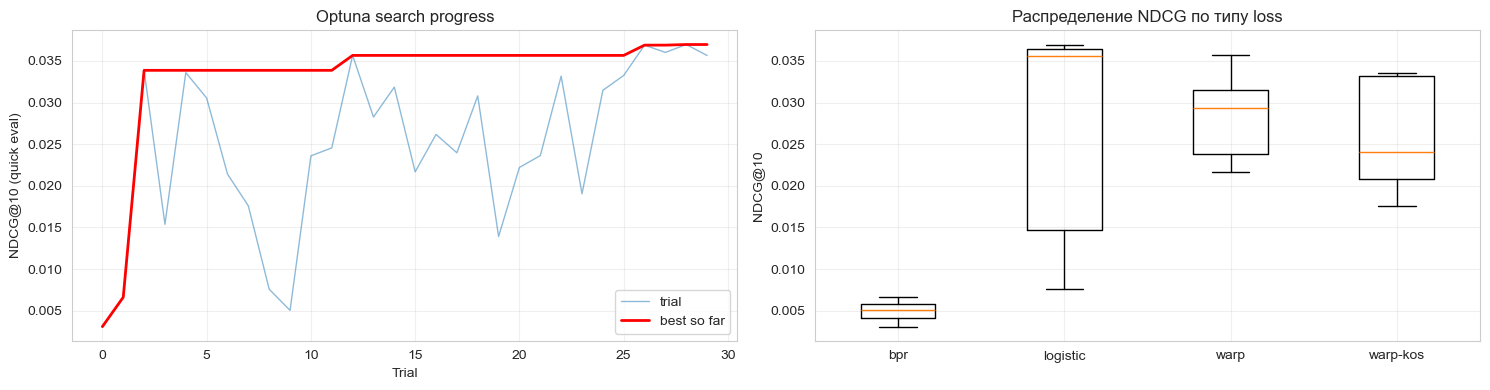

Importance гиперпараметров (по влиянию на NDCG@10):
  loss               0.374
  item_alpha         0.205
  learning_rate      0.202
  no_components      0.106
  user_alpha         0.104
  learning_schedule  0.009

BEST_PARAMS = {'loss': 'logistic', 'no_components': 16, 'learning_rate': 0.0797000809388546, 'learning_schedule': 'adagrad', 'item_alpha': 2.568942102530849e-06, 'user_alpha': 1.5400162174710275e-06}


In [40]:
trials_df = study.trials_dataframe()
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(trials_df['number'], trials_df['value'], alpha=0.5, linewidth=1, label='trial')
axes[0].plot(trials_df['number'], trials_df['value'].cummax(),
             linewidth=2, color='red', label='best so far')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel(f'NDCG@{SEARCH_K} (quick eval)')
axes[0].set_title('Optuna search progress')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

loss_box = trials_df.groupby('params_loss')['value'].apply(list)
axes[1].boxplot([loss_box[name] for name in loss_box.index], labels=list(loss_box.index))
axes[1].set_ylabel(f'NDCG@{SEARCH_K}')
axes[1].set_title('Распределение NDCG по типу loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

try:
    importance = optuna.importance.get_param_importances(study)
    print('Importance гиперпараметров (по влиянию на NDCG@10):')
    for k, v in importance.items():
        print(f'  {k:18s} {v:.3f}')
except Exception as e:
    print(f'Importance не посчитан: {e}')

BEST_PARAMS = dict(DEFAULT_PARAMS)
BEST_PARAMS.update(study.best_params)
if BEST_PARAMS.get('loss') not in ('warp', 'warp-kos'):
    BEST_PARAMS.pop('max_sampled', None)
print(f'\nBEST_PARAMS = {BEST_PARAMS}')

## 6. Анализ влияния групп фичей

Все варианты учатся с `BEST_PARAMS` и `FINAL_EPOCHS` на одном и том же train/test.
Сравниваем 4 базовых блока:

- **no_features** — identity only (классический MF, без сторонних фичей).
- **only_user** — identity + 12 пользовательских фичей.
- **only_item** — identity + 93 товарных фичи.
- **all** — пользовательские + товарные.

Это позволит увидеть, какая сторона (user или item) даёт основной прирост.

In [41]:
FEATURE_VARIANTS = [
    ('no_features', 'none', 'none'),
    ('only_user',   'base', 'none'),
    ('only_item',   'none', 'base'),
    ('all',         'base', 'base'),
]

feature_results = {}
for label, um, im in FEATURE_VARIANTS:
    u_mat, i_mat, ua, ia = build_dataset(um, im)
    print(f'>>> {label:12s}  user-side={len(ua):3d}  item-side={len(ia):3d}  ...', end=' ', flush=True)
    model = fit_lightfm(BEST_PARAMS, u_mat, i_mat, epochs=FINAL_EPOCHS)
    res   = evaluate_lightfm(model, u_mat, i_mat, all_eval_users)
    feature_results[label] = res
    print(f'NDCG@10={res[10]["ndcg"]:.4f}  P@10={res[10]["precision"]:.4f}')

>>> no_features   user-side=  0  item-side=  0  ... NDCG@10=0.0424  P@10=0.0190
>>> only_user     user-side= 12  item-side=  0  ... NDCG@10=0.0429  P@10=0.0194
>>> only_item     user-side=  0  item-side= 93  ... NDCG@10=0.0307  P@10=0.0123
>>> all           user-side= 12  item-side= 93  ... NDCG@10=0.0293  P@10=0.0109


In [42]:
def results_to_df(results_dict, k_values=K_VALUES):
    rows = []
    for label, res in results_dict.items():
        for k in k_values:
            r = res[k]
            rows.append({
                'Вариант':   label,
                'K':         k,
                'Precision': round(r['precision'], 4),
                'Recall':    round(r['recall'],    4),
                'MAP':       round(r['map'],       4),
                'NDCG':      round(r['ndcg'],      4),
            })
    return pd.DataFrame(rows)

feature_df = results_to_df(feature_results)
feature_df_pivot = feature_df.pivot(index='Вариант', columns='K')
print(feature_df.to_string(index=False))
feature_df_pivot

    Вариант  K  Precision  Recall    MAP   NDCG
no_features  5     0.0196  0.0314 0.0224 0.0332
no_features 10     0.0190  0.0571 0.0245 0.0424
no_features 20     0.0180  0.0885 0.0270 0.0538
  only_user  5     0.0198  0.0315 0.0227 0.0335
  only_user 10     0.0194  0.0580 0.0248 0.0429
  only_user 20     0.0182  0.0884 0.0273 0.0541
  only_item  5     0.0203  0.0264 0.0214 0.0322
  only_item 10     0.0123  0.0291 0.0195 0.0307
  only_item 20     0.0072  0.0317 0.0191 0.0305
        all  5     0.0167  0.0231 0.0199 0.0289
        all 10     0.0109  0.0295 0.0189 0.0293
        all 20     0.0067  0.0323 0.0186 0.0296


Precision                  Recall                     MAP          \
K                  5       10      20      5       10      20      5       10   
Вариант                                                                         
all            0.0167  0.0109  0.0067  0.0231  0.0295  0.0323  0.0199  0.0189   
no_features    0.0196  0.0190  0.0180  0.0314  0.0571  0.0885  0.0224  0.0245   
only_item      0.0203  0.0123  0.0072  0.0264  0.0291  0.0317  0.0214  0.0195   
only_user      0.0198  0.0194  0.0182  0.0315  0.0580  0.0884  0.0227  0.0248   

                       NDCG                  
K                20      5       10      20  
Вариант                                      
all          0.0186  0.0289  0.0293  0.0296  
no_features  0.0270  0.0332  0.0424  0.0538  
only_item    0.0191  0.0322  0.0307  0.0305  
only_user    0.0273  0.0335  0.0429  0.0541

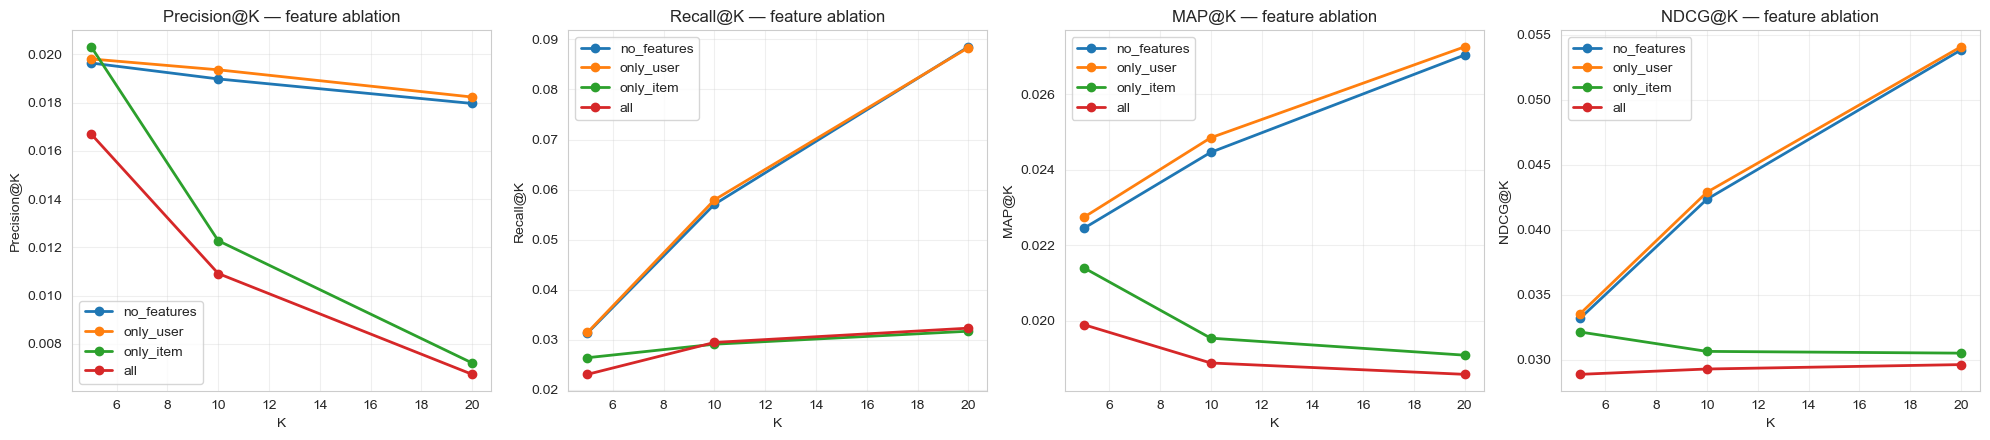

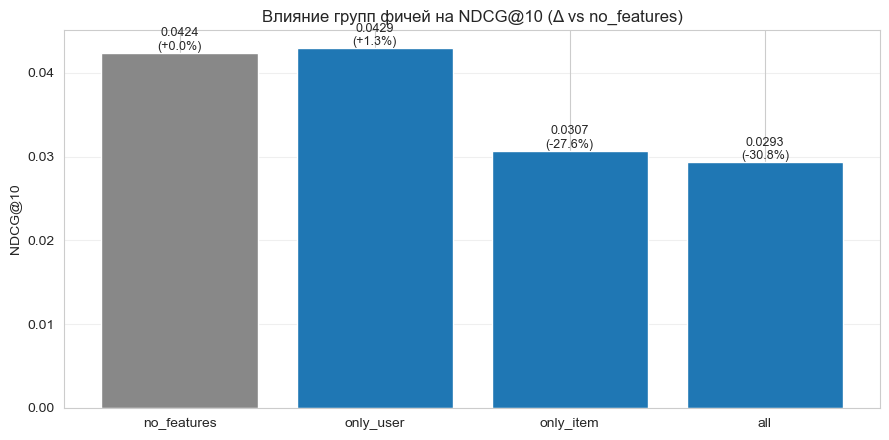

In [43]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
metric_names = ['Precision', 'Recall', 'MAP', 'NDCG']
metric_keys  = ['precision', 'recall', 'map', 'ndcg']

for ax, mname, mkey in zip(axes, metric_names, metric_keys):
    for label, res in feature_results.items():
        ys = [res[k][mkey] for k in K_VALUES]
        ax.plot(K_VALUES, ys, marker='o', linewidth=2, label=label)
    ax.set_xlabel('K')
    ax.set_ylabel(f'{mname}@K')
    ax.set_title(f'{mname}@K — feature ablation')
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
labels = [v[0] for v in FEATURE_VARIANTS]
vals   = [feature_results[l][SEARCH_K]['ndcg'] for l in labels]
base   = feature_results['no_features'][SEARCH_K]['ndcg']
colors = ['#888'] + ['#1f77b4'] * 3
bars = ax.bar(labels, vals, color=colors)
for b, v in zip(bars, vals):
    delta = (v - base) / base * 100 if base > 0 else 0
    ax.annotate(f'{v:.4f}\n({delta:+.1f}%)',
                xy=(b.get_x() + b.get_width()/2, v),
                ha='center', va='bottom', fontsize=9)
ax.set_ylabel(f'NDCG@{SEARCH_K}')
ax.set_title(f'Влияние групп фичей на NDCG@{SEARCH_K} (Δ vs no_features)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [44]:
CLUSTER_VARIANTS = [
    ('all',              'base',         'base'),
    ('all + kmeans',     'base+cluster', 'base'),
    ('only_clusters',    'cluster',      'none'),
    ('clusters + item',  'cluster',      'base'),
]

cluster_results = {}
for label, um, im in CLUSTER_VARIANTS:
    u_mat, i_mat, ua, ia = build_dataset(um, im)
    print(f'>>> {label:18s}  user-side={len(ua):3d}  item-side={len(ia):3d}  ...', end=' ', flush=True)
    model = fit_lightfm(BEST_PARAMS, u_mat, i_mat, epochs=FINAL_EPOCHS)
    res   = evaluate_lightfm(model, u_mat, i_mat, all_eval_users)
    cluster_results[label] = res
    print(f'NDCG@10={res[10]["ndcg"]:.4f}  P@10={res[10]["precision"]:.4f}')

>>> all                 user-side= 12  item-side= 93  ... NDCG@10=0.0293  P@10=0.0109
>>> all + kmeans        user-side= 19  item-side= 93  ... NDCG@10=0.0280  P@10=0.0097
>>> only_clusters       user-side=  7  item-side=  0  ... NDCG@10=0.0425  P@10=0.0194
>>> clusters + item     user-side=  7  item-side= 93  ... NDCG@10=0.0269  P@10=0.0100


In [45]:
cluster_df_metrics = results_to_df(cluster_results)
print(cluster_df_metrics.to_string(index=False))

all_ndcg10        = cluster_results['all'][SEARCH_K]['ndcg']
all_kmeans_ndcg10 = cluster_results['all + kmeans'][SEARCH_K]['ndcg']
delta = (all_kmeans_ndcg10 - all_ndcg10) / all_ndcg10 * 100 if all_ndcg10 > 0 else 0
print(f'\nΔ NDCG@10 ((all + kmeans) − all) = {all_kmeans_ndcg10 - all_ndcg10:+.4f} ({delta:+.2f}%)')
for k in K_VALUES:
    a = cluster_results['all'][k]['ndcg']
    b = cluster_results['all + kmeans'][k]['ndcg']
    d = (b - a) / a * 100 if a > 0 else 0
    print(f'  K={k:2d}  all={a:.4f}  all+kmeans={b:.4f}  Δ={d:+.2f}%')

        Вариант  K  Precision  Recall    MAP   NDCG
            all  5     0.0167  0.0231 0.0199 0.0289
            all 10     0.0109  0.0295 0.0189 0.0293
            all 20     0.0067  0.0323 0.0186 0.0296
   all + kmeans  5     0.0179  0.0258 0.0201 0.0300
   all + kmeans 10     0.0097  0.0276 0.0182 0.0280
   all + kmeans 20     0.0055  0.0291 0.0178 0.0278
  only_clusters  5     0.0185  0.0285 0.0219 0.0319
  only_clusters 10     0.0194  0.0580 0.0244 0.0425
  only_clusters 20     0.0179  0.0864 0.0266 0.0530
clusters + item  5     0.0176  0.0234 0.0194 0.0289
clusters + item 10     0.0100  0.0249 0.0174 0.0269
clusters + item 20     0.0061  0.0279 0.0171 0.0271

Δ NDCG@10 ((all + kmeans) − all) = -0.0013 (-4.41%)
  K= 5  all=0.0289  all+kmeans=0.0300  Δ=+3.97%
  K=10  all=0.0293  all+kmeans=0.0280  Δ=-4.41%
  K=20  all=0.0296  all+kmeans=0.0278  Δ=-6.18%


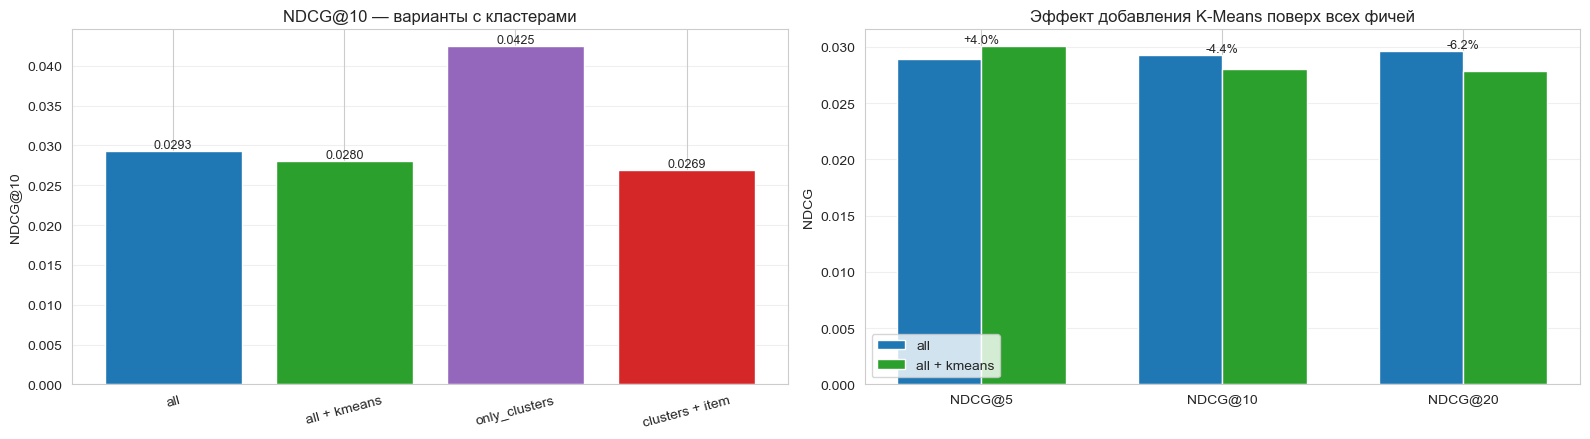

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
labels  = [v[0] for v in CLUSTER_VARIANTS]
ndcg10  = [cluster_results[l][SEARCH_K]['ndcg'] for l in labels]
colors  = ['#1f77b4', '#2ca02c', '#9467bd', '#d62728']
bars = axes[0].bar(labels, ndcg10, color=colors)
for b, v in zip(bars, ndcg10):
    axes[0].annotate(f'{v:.4f}',
                     xy=(b.get_x() + b.get_width()/2, v),
                     ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel(f'NDCG@{SEARCH_K}')
axes[0].set_title(f'NDCG@{SEARCH_K} — варианты с кластерами')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, alpha=0.3, axis='y')

x = np.arange(len(K_VALUES))
width = 0.35
vals_a = [cluster_results['all'][k]['ndcg'] for k in K_VALUES]
vals_b = [cluster_results['all + kmeans'][k]['ndcg'] for k in K_VALUES]
axes[1].bar(x - width/2, vals_a, width, label='all',          color='#1f77b4')
axes[1].bar(x + width/2, vals_b, width, label='all + kmeans', color='#2ca02c')
for j, k in enumerate(K_VALUES):
    delta = (vals_b[j] - vals_a[j]) / vals_a[j] * 100 if vals_a[j] > 0 else 0
    axes[1].annotate(f'{delta:+.1f}%',
                     xy=(j, max(vals_a[j], vals_b[j])),
                     ha='center', va='bottom', fontsize=9)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'NDCG@{k}' for k in K_VALUES])
axes[1].set_ylabel('NDCG')
axes[1].set_title('Эффект добавления K-Means поверх всех фичей')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [47]:
COLD_VARIANTS = [
    ('no_features',     'none',         'none'),
    ('only_user',       'base',         'none'),
    ('only_item',       'none',         'base'),
    ('all',             'base',         'base'),
    ('only_clusters',   'cluster',      'none'),
    ('all + kmeans',    'base+cluster', 'base'),
    ('clusters + item', 'cluster',      'base'),
]

cold_warm_results = {}
if len(cold_eval_users) == 0:
    print('Cold cohort пуст — все тестовые юзеры есть в train. Секция пропускается.')
else:
    for label, um, im in COLD_VARIANTS:
        u_mat, i_mat, _, _ = build_dataset(um, im)
        print(f'>>> {label:18s}  ...', end=' ', flush=True)
        model = fit_lightfm(BEST_PARAMS, u_mat, i_mat, epochs=FINAL_EPOCHS)
        warm_res = evaluate_lightfm(model, u_mat, i_mat, all_eval_users,
                                    test_dict=test_user_items)
        cold_res = evaluate_lightfm(model, u_mat, i_mat, cold_eval_users,
                                    test_dict=cold_test_user_items)
        cold_warm_results[label] = {'warm': warm_res, 'cold': cold_res}
        print(f'warm NDCG@10={warm_res[10]["ndcg"]:.4f}   cold NDCG@10={cold_res[10]["ndcg"]:.4f}')

>>> no_features         ... warm NDCG@10=0.0424   cold NDCG@10=0.0187
>>> only_user           ... warm NDCG@10=0.0429   cold NDCG@10=0.0187
>>> only_item           ... warm NDCG@10=0.0307   cold NDCG@10=0.0151
>>> all                 ... warm NDCG@10=0.0293   cold NDCG@10=0.0143
>>> only_clusters       ... warm NDCG@10=0.0425   cold NDCG@10=0.0185
>>> all + kmeans        ... warm NDCG@10=0.0280   cold NDCG@10=0.0137
>>> clusters + item     ... warm NDCG@10=0.0269   cold NDCG@10=0.0133


In [48]:
if cold_warm_results:
    rows = []
    for label, res in cold_warm_results.items():
        for cohort in ('warm', 'cold'):
            for k in K_VALUES:
                r = res[cohort][k]
                rows.append({
                    'Вариант':   label,
                    'Cohort':    cohort,
                    'K':         k,
                    'Precision': round(r['precision'], 4),
                    'Recall':    round(r['recall'],    4),
                    'MAP':       round(r['map'],       4),
                    'NDCG':      round(r['ndcg'],      4),
                })
    cold_warm_df = pd.DataFrame(rows)

    pivot = (cold_warm_df[cold_warm_df['K'] == SEARCH_K]
             .pivot(index='Вариант', columns='Cohort', values='NDCG')
             .reindex([v[0] for v in COLD_VARIANTS]))
    pivot['cold/warm'] = pivot['cold'] / pivot['warm'].replace(0, np.nan)
    print(f'NDCG@{SEARCH_K} по когортам:')
    print(pivot.round(4).to_string())

NDCG@10 по когортам:
Cohort             cold    warm  cold/warm
Вариант                                   
no_features      0.0187  0.0424     0.4410
only_user        0.0187  0.0429     0.4359
only_item        0.0151  0.0307     0.4919
all              0.0143  0.0293     0.4881
only_clusters    0.0185  0.0425     0.4353
all + kmeans     0.0137  0.0280     0.4893
clusters + item  0.0133  0.0269     0.4944


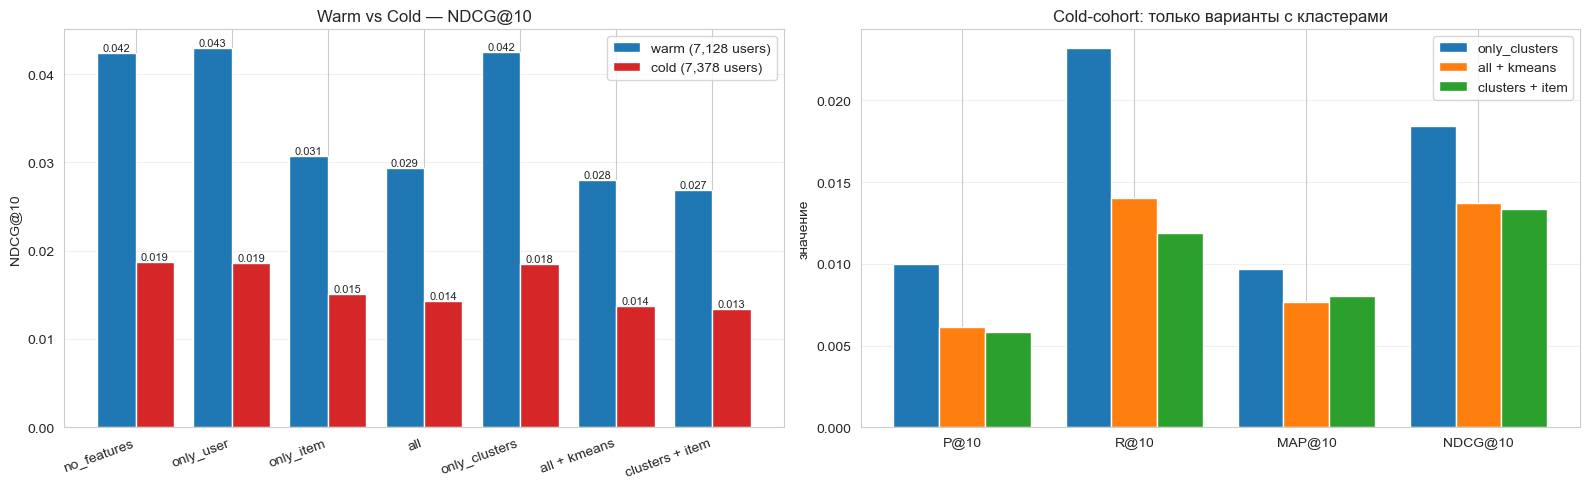

In [49]:
if cold_warm_results:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    labels    = [v[0] for v in COLD_VARIANTS]
    warm_vals = [cold_warm_results[l]['warm'][SEARCH_K]['ndcg'] for l in labels]
    cold_vals = [cold_warm_results[l]['cold'][SEARCH_K]['ndcg'] for l in labels]

    x = np.arange(len(labels))
    width = 0.4
    axes[0].bar(x - width/2, warm_vals, width,
                label=f'warm ({len(all_eval_users):,} users)',  color='#1f77b4')
    axes[0].bar(x + width/2, cold_vals, width,
                label=f'cold ({len(cold_eval_users):,} users)', color='#d62728')
    for i, (w, c) in enumerate(zip(warm_vals, cold_vals)):
        axes[0].annotate(f'{w:.3f}', xy=(i - width/2, w), ha='center', va='bottom', fontsize=8)
        axes[0].annotate(f'{c:.3f}', xy=(i + width/2, c), ha='center', va='bottom', fontsize=8)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=20, ha='right')
    axes[0].set_ylabel(f'NDCG@{SEARCH_K}')
    axes[0].set_title(f'Warm vs Cold — NDCG@{SEARCH_K}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')

    metric_keys  = ['precision', 'recall', 'map', 'ndcg']
    metric_names = ['P', 'R', 'MAP', 'NDCG']
    cold_only = ['only_clusters', 'all + kmeans', 'clusters + item']
    cold_only = [l for l in cold_only if l in cold_warm_results]
    width2 = 0.8 / max(len(cold_only), 1)
    base_x = np.arange(len(metric_keys))
    for j, label in enumerate(cold_only):
        ys = [cold_warm_results[label]['cold'][SEARCH_K][k] for k in metric_keys]
        axes[1].bar(base_x + (j - len(cold_only)/2 + 0.5) * width2, ys, width2, label=label)
    axes[1].set_xticks(base_x)
    axes[1].set_xticklabels([f'{m}@{SEARCH_K}' for m in metric_names])
    axes[1].set_ylabel('значение')
    axes[1].set_title('Cold-cohort: только варианты с кластерами')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

In [50]:
summary_results = {
    'baseline (default, all)': baseline_results,
    **{f'feat:{k}': v for k, v in feature_results.items()},
    **{f'cluster:{k}': v for k, v in cluster_results.items() if k not in ('all',)},
}
summary_df = results_to_df(summary_results)
summary_df_pivot = summary_df.pivot(index='Вариант', columns='K')
summary_df_pivot = summary_df_pivot.sort_values(('NDCG', 10), ascending=False)
summary_df_pivot

Precision                  Recall                  \
K                              5       10      20      5       10      20   
Вариант                                                                     
feat:only_user             0.0198  0.0194  0.0182  0.0315  0.0580  0.0884   
cluster:only_clusters      0.0185  0.0194  0.0179  0.0285  0.0580  0.0864   
feat:no_features           0.0196  0.0190  0.0180  0.0314  0.0571  0.0885   
feat:only_item             0.0203  0.0123  0.0072  0.0264  0.0291  0.0317   
feat:all                   0.0167  0.0109  0.0067  0.0231  0.0295  0.0323   
cluster:all + kmeans       0.0179  0.0097  0.0055  0.0258  0.0276  0.0291   
baseline (default, all)    0.0184  0.0155  0.0129  0.0199  0.0330  0.0508   
cluster:clusters + item    0.0176  0.0100  0.0061  0.0234  0.0249  0.0279   

                            MAP                    NDCG                  
K                            5       10      20      5       10      20  
Вариант                                                                  
feat:only_user           0.0227  0.0248  0.0273  0.0335  0.0429  0.0541  
cluster:only_clusters    0.0219  0.0244  0.0266  0.0319  0.0425  0.0530  
feat:no_features         0.0224  0.0245  0.0270  0.0332  0.0424  0.0538  
feat:only_item           0.0214  0.0195  0.0191  0.0322  0.0307  0.0305  
feat:all                 0.0199  0.0189  0.0186  0.0289  0.0293  0.0296  
cluster:all + kmeans     0.0201  0.0182  0.0178  0.0300  0.0280  0.0278  
baseline (default, all)  0.0144  0.0139  0.0145  0.0239  0.0270  0.0324  
cluster:clusters + item  0.0194  0.0174  0.0171  0.0289  0.0269  0.0271

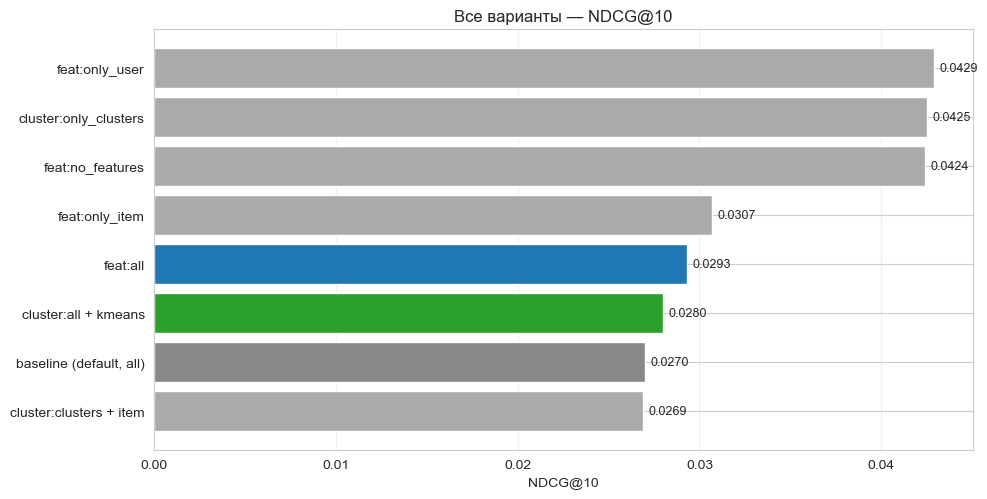

In [51]:
ranking = summary_df[summary_df['K'] == SEARCH_K].sort_values('NDCG', ascending=True)
fig, ax = plt.subplots(figsize=(10, 0.45 * len(ranking) + 1.5))
colors = []
for label in ranking['Вариант']:
    if 'kmeans' in label:
        colors.append('#2ca02c')
    elif label == 'feat:all':
        colors.append('#1f77b4')
    elif label.startswith('baseline'):
        colors.append('#888')
    else:
        colors.append('#aaa')
bars = ax.barh(ranking['Вариант'], ranking['NDCG'], color=colors)
for b, v in zip(bars, ranking['NDCG']):
    ax.annotate(f'{v:.4f}',
                xy=(v, b.get_y() + b.get_height()/2),
                xytext=(4, 0), textcoords='offset points',
                ha='left', va='center', fontsize=9)
ax.set_xlabel(f'NDCG@{SEARCH_K}')
ax.set_title(f'Все варианты — NDCG@{SEARCH_K}')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [52]:
# Item-фичи v2: multi-hot из полного df (не train_raw + mode), drop редких, log-price
catalog_agg = df.groupby('ID_SKU').agg(
    g2_set=('Группа2', lambda s: list(s.dropna().unique())),
    g3_set=('Группа3', lambda s: list(s.dropna().unique())),
    type_set=('Тип',   lambda s: list(s.dropna().unique())),
    median_price=('Цена', 'median'),
).reset_index()
catalog_agg['item_id'] = catalog_agg['ID_SKU'].map(item2id)
catalog_agg = catalog_agg.dropna(subset=['item_id']).copy()
catalog_agg['item_id'] = catalog_agg['item_id'].astype(int)

# Log(median price) → 5 квантильных бинов (медиана устойчивее к выбросам, чем mean)
median_fallback = catalog_agg['median_price'].median()
log_price = np.log1p(catalog_agg['median_price'].fillna(median_fallback))
catalog_agg['price_bin_v2'] = pd.qcut(
    log_price, q=5,
    labels=[f'price_v2_q{i}' for i in range(5)],
    duplicates='drop',
).astype(str)


def _expand(prefix, vals):
    return [f'{prefix}_{v}' for v in vals]


catalog_feats_raw = {
    int(row['item_id']): (
        _expand('g2',   row['g2_set']) +
        _expand('g3',   row['g3_set']) +
        _expand('type', row['type_set']) +
        [row['price_bin_v2']]
    )
    for _, row in catalog_agg.iterrows()
}

# Дроп редких фич: покрытие < MIN_FEAT_COUNT — не несут сигнала, только шумят
MIN_FEAT_COUNT = 30
all_feats_flat = pd.Series([f for fs in catalog_feats_raw.values() for f in fs])
feat_counts = all_feats_flat.value_counts()
keep_feats = set(feat_counts[feat_counts >= MIN_FEAT_COUNT].index)

catalog_item_feats = {
    iid: [f for f in fs if f in keep_feats]
    for iid, fs in catalog_feats_raw.items()
}
catalog_item_feats = {iid: fs for iid, fs in catalog_item_feats.items() if fs}

n_unique_v2 = len({f for fs in catalog_item_feats.values() for f in fs})
mean_per_item = np.mean([len(fs) for fs in catalog_item_feats.values()])
print(f'V2 catalog item-features:')
print(f'  Уникальных фич (после фильтра ≥{MIN_FEAT_COUNT} items): {n_unique_v2}')
print(f'  Items с фичами: {len(catalog_item_feats):,} / {n_items:,} '
      f'({len(catalog_item_feats)/n_items:.1%})')
print(f'  Среднее число фич на item: {mean_per_item:.2f}')
print(f'  Дропнуто редких фич: {(feat_counts < MIN_FEAT_COUNT).sum()} '
      f'из {len(feat_counts)}')


V2 catalog item-features:
  Уникальных фич (после фильтра ≥30 items): 62
  Items с фичами: 8,488 / 22,198 (38.2%)
  Среднее число фич на item: 3.97
  Дропнуто редких фич: 32 из 94


In [53]:
def build_feature_matrix_v2(feature_dict, all_features, n_entities, side_weight=0.5):
    """Identity weight = 1.0; сумма side-фич на item нормирована к side_weight (по умолчанию 0.5).
    Это сохраняет доминирование id-сигнала: identity не размывается фичами."""
    feat_to_idx = {f: i for i, f in enumerate(all_features)}
    rows, cols, data = [], [], []
    for entity_id, feats in feature_dict.items():
        valid = [f for f in feats if f in feat_to_idx]
        if not valid:
            continue
        w = side_weight / len(valid)
        for f in valid:
            rows.append(entity_id)
            cols.append(feat_to_idx[f])
            data.append(w)
    side = csr_matrix((data, (rows, cols)), shape=(n_entities, len(all_features)))
    identity = eye(n_entities, format='csr')
    return hstack([identity, side], format='csr')


def build_dataset_v2(user_dict=None, item_dict=None, side_weight=0.5):
    if user_dict:
        u_all = sorted({f for fs in user_dict.values() for f in fs})
        u_mat = build_feature_matrix_v2(user_dict, u_all, n_users, side_weight)
    else:
        u_all, u_mat = [], eye(n_users, format='csr')
    if item_dict:
        i_all = sorted({f for fs in item_dict.values() for f in fs})
        i_mat = build_feature_matrix_v2(item_dict, i_all, n_items, side_weight)
    else:
        i_all, i_mat = [], eye(n_items, format='csr')
    return u_mat, i_mat, u_all, i_all


# Основная V2-комбинация: user_base + item_catalog
u_mat_v2, i_mat_v2, ua_v2, ia_v2 = build_dataset_v2(
    user_dict=base_user_feats,
    item_dict=catalog_item_feats,
    side_weight=0.5,
)
print(f'V2 dataset: U {u_mat_v2.shape} ({len(ua_v2)} side), I {i_mat_v2.shape} ({len(ia_v2)} side)')


V2 dataset: U (35395, 35407) (12 side), I (22198, 22260) (62 side)


In [54]:
# WARP с честным сетапом: 30 эпох, низкий LR, высокий max_sampled,
# eval на расширенной выборке (1500 users) — меньше шума при сравнении trial-ов.
WARP_EPOCHS = 30
WARP_TRIALS = 15
EVAL_USERS_WARP = 1500

rng_warp = np.random.RandomState(SEED + 1)
warp_eval_users = rng_warp.choice(
    all_eval_users,
    size=min(EVAL_USERS_WARP, len(all_eval_users)),
    replace=False,
).tolist()


def warp_objective(trial):
    params = dict(
        loss='warp',
        no_components=trial.suggest_int('no_components', 32, 192, log=True),
        learning_rate=trial.suggest_float('learning_rate', 1e-3, 3e-2, log=True),
        learning_schedule='adagrad',
        item_alpha=trial.suggest_float('item_alpha', 1e-9, 1e-5, log=True),
        user_alpha=trial.suggest_float('user_alpha', 1e-9, 1e-5, log=True),
        max_sampled=trial.suggest_int('max_sampled', 30, 200),
    )
    model = fit_lightfm(params, u_mat_v2, i_mat_v2, epochs=WARP_EPOCHS)
    res = evaluate_lightfm(model, u_mat_v2, i_mat_v2, warp_eval_users, k_values=[SEARCH_K])
    return res[SEARCH_K]['ndcg']


study_warp = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    study_name='LightFM_WARP_v2',
)
study_warp.optimize(warp_objective, n_trials=WARP_TRIALS, show_progress_bar=True)

print(f'\nWARP лучший NDCG@{SEARCH_K} (на {EVAL_USERS_WARP} users): {study_warp.best_value:.4f}')
print('Лучшие параметры:')
for k, v in study_warp.best_params.items():
    print(f'  {k:18s} = {v}')

WARP_BEST = dict(loss='warp', learning_schedule='adagrad', **study_warp.best_params)


  0%|          | 0/15 [00:00<?, ?it/s]


WARP лучший NDCG@10 (на 1500 users): 0.0437
Лучшие параметры:
  no_components      = 62
  learning_rate      = 0.02871393155055542
  item_alpha         = 7.381847215166989e-06
  user_alpha         = 5.239999784712677e-09
  max_sampled        = 59


In [55]:

results_v2 = {}

m1 = fit_lightfm(WARP_BEST, u_mat_v2, i_mat_v2, epochs=WARP_EPOCHS)
results_v2['WARP-tuned + user_base + item_catalog'] = {
    'warm': evaluate_lightfm(m1, u_mat_v2, i_mat_v2, all_eval_users),
    'cold': evaluate_lightfm(m1, u_mat_v2, i_mat_v2, cold_eval_users,
                             test_dict=cold_test_user_items),
}
print(f'  m1 done: warm NDCG@10={results_v2["WARP-tuned + user_base + item_catalog"]["warm"][10]["ndcg"]:.4f}')

u_only, i_no, _, _ = build_dataset_v2(user_dict=base_user_feats, item_dict=None)
m2 = fit_lightfm(WARP_BEST, u_only, i_no, epochs=WARP_EPOCHS)
results_v2['WARP-tuned + user_base only'] = {
    'warm': evaluate_lightfm(m2, u_only, i_no, all_eval_users),
    'cold': evaluate_lightfm(m2, u_only, i_no, cold_eval_users,
                             test_dict=cold_test_user_items),
}
print(f'  m2 done: warm NDCG@10={results_v2["WARP-tuned + user_base only"]["warm"][10]["ndcg"]:.4f}')


u_no, i_no2, _, _ = build_dataset_v2(user_dict=None, item_dict=None)
m3 = fit_lightfm(WARP_BEST, u_no, i_no2, epochs=WARP_EPOCHS)
results_v2['WARP-tuned + no features'] = {
    'warm': evaluate_lightfm(m3, u_no, i_no2, all_eval_users),
    'cold': evaluate_lightfm(m3, u_no, i_no2, cold_eval_users,
                             test_dict=cold_test_user_items),
}
print(f'  m3 done: warm NDCG@10={results_v2["WARP-tuned + no features"]["warm"][10]["ndcg"]:.4f}')

# Сводка V2
print('\n=== V2 @ K=10 (warm + cold) ===')
print(f"{'Вариант':<46s} {'cohort':>5s}  {'P':>7s}  {'R':>7s}  {'MAP':>7s}  {'NDCG':>7s}")
for label, by_cohort in results_v2.items():
    for cohort in ('warm', 'cold'):
        r = by_cohort[cohort][10]
        print(f"{label:<46s} {cohort:>5s}  {r['precision']:>7.4f}  {r['recall']:>7.4f}  "
              f"{r['map']:>7.4f}  {r['ndcg']:>7.4f}")


print('\n=== V1 (старая обработка) vs V2 (новая) — NDCG@10 на warm cohort ===')
rows = [
    ('V1 baseline (WARP default + old all)',         baseline_results[10]['ndcg']),
    ('V1 logistic-Optuna + old all',                 feature_results['all'][10]['ndcg']),
    ('V1 logistic-Optuna + only_user',               feature_results['only_user'][10]['ndcg']),
    ('V2 WARP-tuned + only_user (без item)',         results_v2['WARP-tuned + user_base only']['warm'][10]['ndcg']),
    ('V2 WARP-tuned + user + catalog item-фичи',     results_v2['WARP-tuned + user_base + item_catalog']['warm'][10]['ndcg']),
]
best = max(r[1] for r in rows)
for label, v in rows:
    mark = '  <-- best' if v == best else ''
    print(f'  {label:<46s} {v:.4f}{mark}')


  m1 done: warm NDCG@10=0.0488
  m2 done: warm NDCG@10=0.0595
  m3 done: warm NDCG@10=0.0727

=== V2 @ K=10 (warm + cold) ===
Вариант                                        cohort        P        R      MAP     NDCG
WARP-tuned + user_base + item_catalog           warm   0.0270   0.0586   0.0273   0.0488
WARP-tuned + user_base + item_catalog           cold   0.0099   0.0252   0.0103   0.0196
WARP-tuned + user_base only                     warm   0.0329   0.0725   0.0339   0.0595
WARP-tuned + user_base only                     cold   0.0097   0.0251   0.0096   0.0188
WARP-tuned + no features                        warm   0.0400   0.0815   0.0440   0.0727
WARP-tuned + no features                        cold   0.0097   0.0248   0.0101   0.0193

=== V1 (старая обработка) vs V2 (новая) — NDCG@10 на warm cohort ===
  V1 baseline (WARP default + old all)           0.0270
  V1 logistic-Optuna + old all                   0.0293
  V1 logistic-Optuna + only_user                 0.0429
  V2 WARP-tu